# The irreducible mass of black holes.

In [63]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats

In [178]:
sigma = 0.02
mu = 1
N = 1000

chi = np.random.uniform(0,1,N)
M = np.random.normal(mu, sigma, N)

def M_irr(chi,M):
    return M*np.sqrt((1+np.sqrt(1-chi**2))/2)

Mirr = M_irr(chi,M)

(array([  5.,  17.,  32.,  43.,  71., 107., 140., 276., 269.,  40.]),
 array([0.69562272, 0.73166546, 0.76770821, 0.80375096, 0.83979371,
        0.87583646, 0.91187921, 0.94792196, 0.9839647 , 1.02000745,
        1.0560502 ]),
 <BarContainer object of 10 artists>)

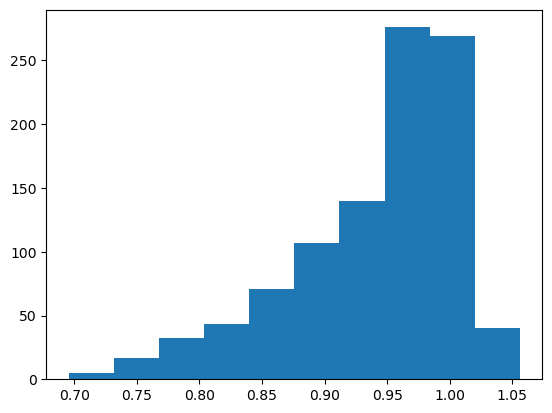

In [179]:
plt.hist(Mirr)

# Scott

0.023446136867436677


(array([  2.,   5.,  13.,  20.,  28.,  25.,  40.,  53.,  67.,  86., 106.,
        169., 233., 119.,  33.,   1.]),
 array([0.69562272, 0.71906885, 0.74251499, 0.76596113, 0.78940726,
        0.8128534 , 0.83629954, 0.85974567, 0.88319181, 0.90663795,
        0.93008408, 0.95353022, 0.97697636, 1.00042249, 1.02386863,
        1.04731477, 1.07076091]),
 <BarContainer object of 16 artists>)

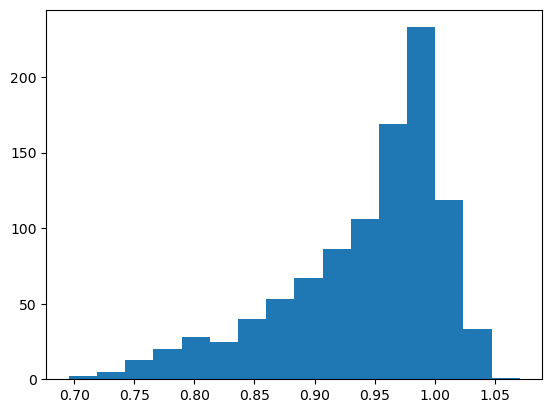

In [180]:
def scott(data):
    sigma = np.std(data)       
    n = len(data)              
    delta = 3.5 * sigma / n**(1/3) 
    bins = np.arange(np.min(data), np.max(data)+delta, delta)
    print(delta)
    return bins
    

plt.hist(Mirr, bins = scott(Mirr))

# Diaconis

0.01691946946448657


(array([  2.,   2.,   6.,   9.,  14.,  13.,  23.,  16.,  26.,  32.,  41.,
         43.,  67.,  56.,  78., 105., 151., 159., 104.,  44.,   8.,   1.]),
 array([0.69562272, 0.71254219, 0.72946165, 0.74638112, 0.76330059,
        0.78022006, 0.79713953, 0.814059  , 0.83097847, 0.84789794,
        0.86481741, 0.88173688, 0.89865635, 0.91557582, 0.93249529,
        0.94941476, 0.96633423, 0.9832537 , 1.00017317, 1.01709264,
        1.0340121 , 1.05093157, 1.06785104]),
 <BarContainer object of 22 artists>)

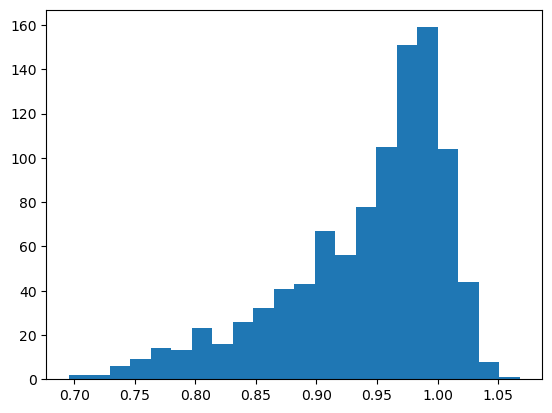

In [181]:
from astroML import stats as astroMLstats

def diac(data):
    sigmaG = astroMLstats.sigmaG(Mirr)     
    n = len(data)              
    delta = 2.7*sigmaG/n**(1/3)
    bins = np.arange(np.min(data), np.max(data)+delta, delta)
    print(delta)
    return bins

plt.hist(Mirr, bins = diac(Mirr))

0.023446136867436677
0.01691946946448657


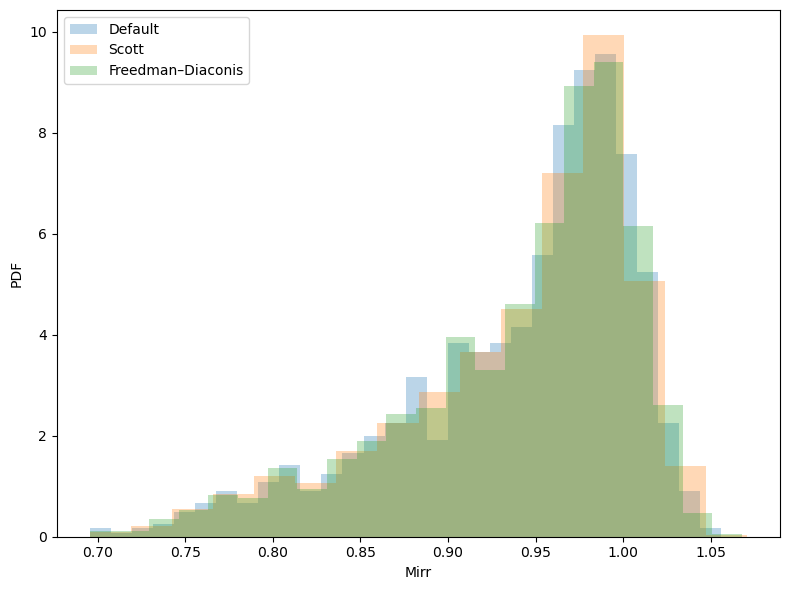

In [182]:
import matplotlib.pyplot as plt

data = Mirr

plt.figure(figsize=(8,6))

plt.hist(data, bins=30, density=True, alpha=0.3, histtype='stepfilled', label='Default')
plt.hist(data, bins=scott(Mirr), density=True, alpha=0.3, histtype='stepfilled', label='Scott')
plt.hist(data, bins=diac(Mirr), density=True, alpha=0.3, histtype='stepfilled', label='Freedman–Diaconis')


plt.xlabel("Mirr")
plt.ylabel("PDF")
plt.legend()
plt.tight_layout()
plt.show()

# KDE

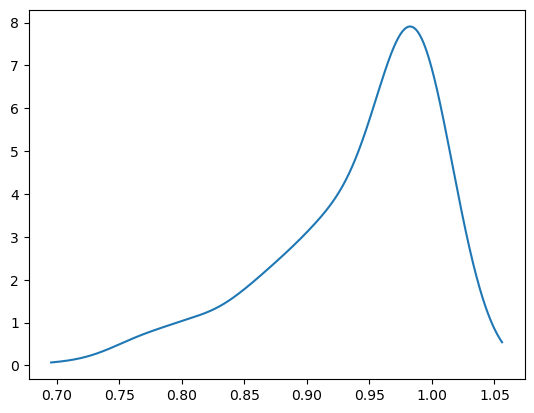

In [183]:
from sklearn.neighbors import KernelDensity

xgrid = np.linspace(Mirr.min(),Mirr.max(),1000)

def kde_sklearn(Mirr, bandwidth = 0.1, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(Mirr[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)


PDFtophat = kde_sklearn(Mirr,bandwidth=0.02, kernel="gaussian") 
plt.plot(xgrid,PDFtophat)

# KS distance

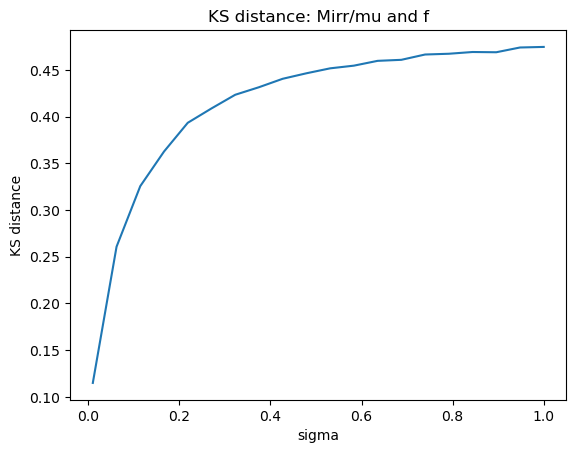

In [184]:
import numpy as np
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

N = 100000
sigmas = np.linspace(0.01, 1.0, 20)

Distance = []

for sigma in sigmas:
    M = np.random.normal(1, sigma, N)
    chi = np.random.uniform(0, 1, N)

    f = np.sqrt((1 + np.sqrt(1 - chi**2)) / 2)
    Mirr_over_mu = M * f

    D, _ = ks_2samp(Mirr_over_mu, f)
    Distance.append(D)

plt.plot(sigmas, Distance)
plt.xlabel("sigma")
plt.ylabel("KS distance")
plt.title('KS distance: Mirr/mu and f')
plt.show()

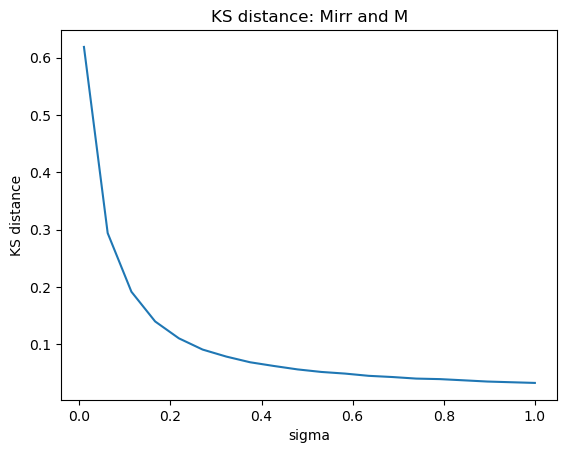

In [185]:
import numpy as np
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

N = 100000
sigmas = np.linspace(0.01, 1.0, 20)

Distance = []

for sigma in sigmas:
    M = np.random.normal(1, sigma, N)
    chi = np.random.uniform(0, 1, N)

    Mirr = np.sqrt((1 + np.sqrt(1 - chi**2)) / 2)*M

    D, _ = ks_2samp(Mirr, M)
    Distance.append(D)

plt.plot(sigmas, Distance)
plt.xlabel("sigma")
plt.ylabel("KS distance")
plt.title('KS distance: Mirr and M')
plt.show()

# $M_{irr}$ distribution

0.010165470845033085
0.018378380459704087
0.15132152103205385
1.5330349133862584
15.449382089935124


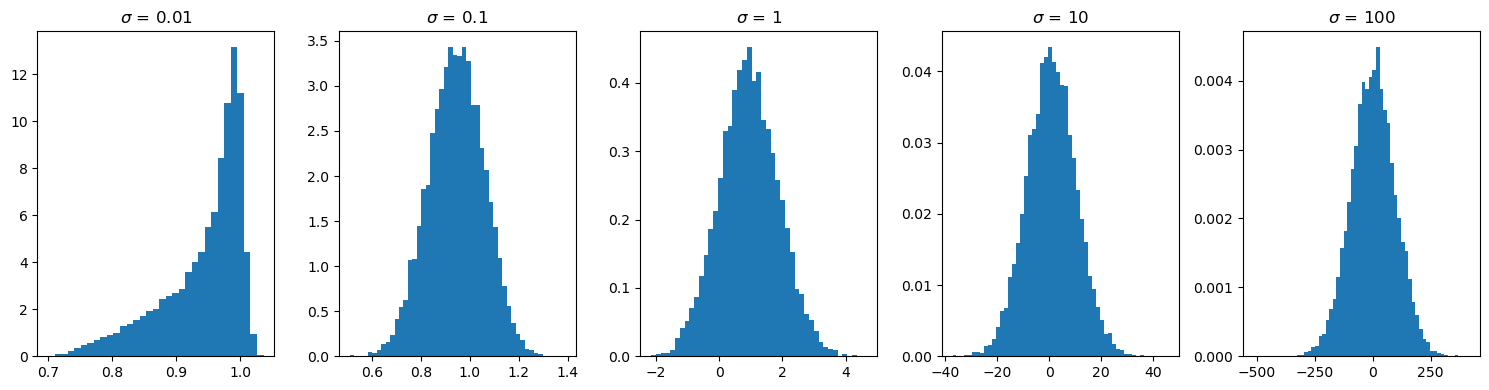

In [186]:
N = 10000
sigmas = [0.01, 0.1, 1, 10, 100]
fig, axes = plt.subplots(1, len(sigmas), figsize=(15,4))


for ax, sigma in zip(axes, sigmas):
    M = np.random.normal(1, sigma, N)
    chi = np.random.uniform(0, 1, N)

    Mirr = np.sqrt((1 + np.sqrt(1 - chi**2)) / 2) * M

    ax.hist(Mirr, bins=scott(Mirr), density=True)
    ax.set_title(f'$\sigma$ = {sigma}')

plt.tight_layout()
plt.show()

# PDFs